In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [3]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 3

In [4]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,),(0.5,))])



In [5]:
train_dataset = torchvision.datasets.MNIST(
    root='./data',        
    train=True,           
    download=True,        
    transform=transform  
)

In [6]:
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,          
    download=True,
    transform=transform
)

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,  
    shuffle=True            
                            
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False           
)

In [8]:
class CNN(nn.Module):

    def __init__(self):

        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()

        self.dropout = nn.Dropout(p=0.25)
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        x = self.conv1(x)     
        x = self.relu1(x)     
        x = self.pool1(x)     

        x = self.conv2(x)     
        x = self.relu2(x)     
        x = self.pool2(x)


        x = x.view(x.size(0), -1)  

        x = self.fc1(x)       
        x = self.relu3(x)     
        x = self.dropout(x)   
        x = self.fc2(x)      

        return x
    

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = CNN()         
model = model.to(device)

Using device: cpu


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [11]:
def train(model, loader, criterion, optimizer, epoch):
    model.train()  

    total_loss = 0
    correct = 0

    for batch_idx, (images, labels) in enumerate(loader):


        images = images.to(device)  
        labels = labels.to(device)

        optimizer.zero_grad()  
        outputs = model(images)

        loss = criterion(outputs, labels)  

        loss.backward()         
        optimizer.step()        

    
        total_loss += loss.item()  
        _, predicted = torch.max(outputs, dim=1)  
        correct += (predicted == labels).sum().item()  

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / len(loader.dataset)
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Train Accuracy: {accuracy:.2f}%")



In [12]:
def evaluate(model, loader, criterion):
    model.eval()  
    total_loss = 0
    correct = 0

    with torch.no_grad():  
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / len(loader.dataset)
    print(f"           Test  Loss: {avg_loss:.4f} | Test  Accuracy: {accuracy:.2f}%")


In [13]:
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, criterion, optimizer, epoch)
    evaluate(model, test_loader, criterion)

print("\nTraining complete!")

Epoch 1 | Train Loss: 0.2487 | Train Accuracy: 92.44%
           Test  Loss: 0.0576 | Test  Accuracy: 98.06%
Epoch 2 | Train Loss: 0.0779 | Train Accuracy: 97.67%
           Test  Loss: 0.0439 | Test  Accuracy: 98.47%
Epoch 3 | Train Loss: 0.0562 | Train Accuracy: 98.33%
           Test  Loss: 0.0384 | Test  Accuracy: 98.85%

Training complete!


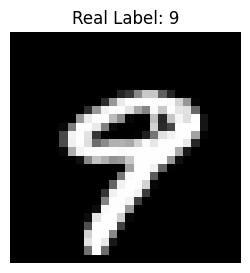

Predicted Label: 9
Real Label: 9


In [16]:

img, real_label = test_dataset[9]

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Real Label: {real_label}")
plt.axis("off")
plt.show()

model.eval()
img_input = img.unsqueeze(0).to(device)

with torch.no_grad():
    out = model(img_input)
    pred_label = torch.argmax(out, dim=1).item()

print("Predicted Label:", pred_label)
print("Real Label:", real_label)